# 气候强迫生成器：对比与论证

## 这个 notebook 在回答什么问题？

审稿人批评说：你的 ABM 气候输入是『每年独立抽一个高斯随机数』，太简单了——真实气候有
**持续性**（今年干旱明年也容易干旱）和**趋势**（长期变干/变湿），你这个模型都没考虑。

我们的回应策略分两步：

1. **先拿真实数据看一看**：年降水到底有没有持续性？φ 是多少？
2. **造四种不同的气候输入**，看差别有多大，为 ABM 敏感性实验做准备。

## 四种气候强迫

| 类型 | 公式 | 大白话 |
|------|------|--------|
| `iid` | $x_t \sim N(0, \sigma^2)$ | 每年独立随机抽，没有『记忆』——这是我们原来的做法 |
| `ar1` | $x_t = \varphi x_{t-1} + \varepsilon_t$ | 今年的气候跟去年有关联（φ 越大关联越强），这叫 AR(1) 自回归过程 |
| `trend_plus_noise` | $x_t = \beta t + \varepsilon_t$ | 气候有一个线性趋势（比如越来越干），叠加随机噪声 |
| `ar1_trend` | $x_t = \beta t + r_t,\ r_t = \varphi r_{t-1} + \varepsilon_t$ | **最真实的**：既有年际持续性，又有长期趋势 |

其中 $\varphi$（phi）是持续性参数（0 = 没持续性 = iid，1 = 完全持续），$\beta$ 是每年的趋势变化量，$\sigma$ 是噪声标准差。

### 加载工具包

下面这个 cell 只是导入需要的 Python 包，并设置一些全局参数：

- `generate`：我们自己写的气候序列生成器（在 `climate_forcing.py` 里）
- `estimate_ar1_phi`：从实际数据反推 φ 的函数
- `statsmodels` / `scipy`：成熟的统计库，用来做对比验证
- `N = 50000`：统计量需要大样本才稳定，所以生成 5 万个点
- `N_SHOW = 300`：画轨迹图只展示前 300 个点，否则太密看不清

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from mksci_font import config_font
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.stattools import acf
from scipy.signal import lfilter

from shifting_baseline.climate_forcing import (
    generate,
    estimate_ar1_phi,
    sigma_tick_from_sigma_year,
)

config_font()
SEED = 42
SIGMA = 1.0
N = 50_000  # 统计用的长样本
N_SHOW = 300  # 画轨迹图用的短样本
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
np.set_printoptions(precision=4, suppress=True)

/Users/songshgeo/Documents/CodeBase/Scholar/shifting_baseline/.venv/lib/python3.11/site-packages/mksci_font/font_wrapper.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


---
## 1. 真实数据的 φ 到底是多少？

在决定 ABM 用什么 φ 之前，最有说服力的做法是：**直接从我们论文用的气候数据里估计 φ**。

我们有两套数据：

- **树轮重建序列**（1000–2013 年）：这是论文里用来和旱涝等级对比的代理数据
- **器测降水数据**（1901–2017 年）：中国北方夏季（JAS）降水的 z-score，作为验证数据

**关键区别**：树轮重建有生物学和统计学上的平滑效应（树木生长是多年的积分），
所以它的 φ 会被人为抬高。器测降水没有这个问题，更能反映『真实』的年际变率。

`estimate_ar1_phi()` 做的事情很简单：算序列的 **lag-1 自相关系数**，也就是『今年的值和去年的值有多相关』。

### 计算经验 φ

下面加载两套数据，调用 `estimate_ar1_phi()` 计算各自的 φ，然后整理成表格。

表格里三列统计量的含义：
- **φ (lag-1 自相关)**：最核心的数，φ ≈ 0 说明没有持续性，φ ≈ 1 说明持续性很强
- **σ_创新项**：AR(1) 过程中每一步『新增』的随机扰动的标准差
- **σ_平稳**：序列整体的标准差（比创新项大，因为持续性会放大方差）

In [2]:
# 加载论文中实际使用的两套气候数据
recon = pd.read_csv("../data/combined_mean.csv", index_col=0)["mean"].dropna()
instr = pd.read_csv("../data/JAS_z_China.csv", index_col=0)["pre"].dropna()

# 用我们自己写的函数估计 AR(1) 系数 φ
est_recon = estimate_ar1_phi(recon.values)
est_instr = estimate_ar1_phi(instr.values)

# 整理成表格方便查看
phi_table = pd.DataFrame(
    {
        "数据": ["树轮重建", "器测降水 (JAS z-score)"],
        "时段": [
            f"{recon.index.min()}\u2013{recon.index.max()} ({len(recon)} 年)",
            f"{instr.index.min()}\u2013{instr.index.max()} ({len(instr)} 年)",
        ],
        "\u03c6 (lag-1 自相关)": [est_recon["phi"], est_instr["phi"]],
        "\u03c3_创新项": [est_recon["sigma_innov"], est_instr["sigma_innov"]],
        "\u03c3_平稳": [est_recon["sigma_stationary"], est_instr["sigma_stationary"]],
    }
)
phi_table.style.format(
    {"\u03c6 (lag-1 自相关)": "{:.4f}", "\u03c3_创新项": "{:.4f}", "\u03c3_平稳": "{:.4f}"}
)

,数据,时段,φ (lag-1 自相关),σ_创新项,σ_平稳
0,树轮重建,1000–2013 (1014 年),0.4960,0.5186,0.5972
1,器测降水 (JAS z-score),1901–2017 (117 年),-0.0985,0.9951,1.0000


### 画自相关函数（ACF）图

下面这张图把两套数据的自相关结构画出来：

- **柱状图**：每个 lag（滞后年数）对应的自相关系数。lag=0 恒为 1（自己跟自己完全相关），
  lag=1 就是『今年跟去年的相关性』，lag=2 是『今年跟前年』，以此类推。
- **红色虚线**：如果这个序列真的服从 AR(1)，理论上 lag-k 的 ACF = φᵏ（指数衰减）。
  红线和蓝柱贴得越近，说明 AR(1) 模型越能描述这个序列。
- **灰色点线**：95% 白噪声置信区间。如果柱子没超出这个范围，说明跟白噪声没有显著区别。

**我们期望看到什么？** 器测降水的柱子应该很矮（接近 iid），树轮的柱子会高一些（平滑导致的假持续性）。

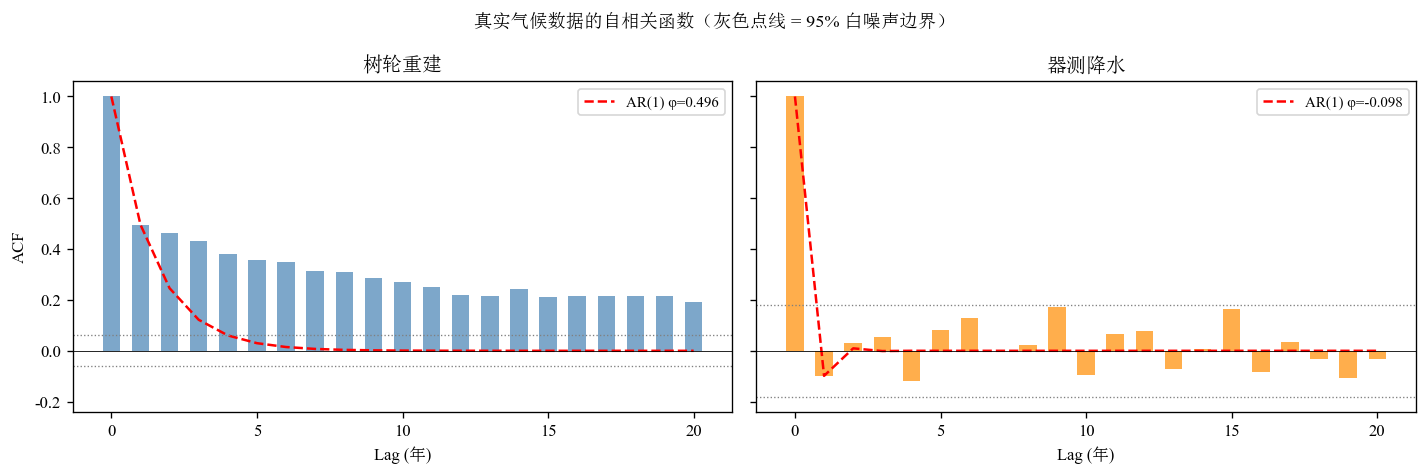


★ 关键发现：
  器测年降水的 φ ≈ -0.10，几乎就是白噪声（iid）！
  树轮重建的 φ ≈ 0.50，但这是树木年轮学平滑造成的假象。
  → 我们 ABM 用 iid 作为基线，在经验上是站得住脚的。


In [3]:
max_lag = 20
acf_recon = acf(recon.values, nlags=max_lag, fft=True)
acf_instr = acf(instr.values, nlags=max_lag, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
lags = np.arange(max_lag + 1)

# 左图：树轮重建
axes[0].bar(lags, acf_recon, width=0.6, color="steelblue", alpha=0.7)
phi_r = est_recon["phi"]
axes[0].plot(lags, phi_r**lags, "r--", lw=1.5, label=f"AR(1) \u03c6={phi_r:.3f}")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].axhline(1.96 / np.sqrt(len(recon)), color="gray", ls=":", lw=0.8)
axes[0].axhline(-1.96 / np.sqrt(len(recon)), color="gray", ls=":", lw=0.8)
axes[0].set_title("树轮重建")
axes[0].set_xlabel("Lag (年)")
axes[0].set_ylabel("ACF")
axes[0].legend(fontsize=9)

# 右图：器测降水
axes[1].bar(lags, acf_instr, width=0.6, color="darkorange", alpha=0.7)
phi_i = est_instr["phi"]
axes[1].plot(lags, phi_i**lags, "r--", lw=1.5, label=f"AR(1) \u03c6={phi_i:.3f}")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axhline(1.96 / np.sqrt(len(instr)), color="gray", ls=":", lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(len(instr)), color="gray", ls=":", lw=0.8)
axes[1].set_title("器测降水")
axes[1].set_xlabel("Lag (年)")
axes[1].legend(fontsize=9)

fig.suptitle("真实气候数据的自相关函数（灰色点线 = 95% 白噪声边界）", fontsize=11)
plt.tight_layout()
plt.savefig("results/empirical_acf.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\n\u2605 关键发现：")
print(f"  器测年降水的 \u03c6 \u2248 {phi_i:.2f}，几乎就是白噪声（iid）！")
print(f"  树轮重建的 \u03c6 \u2248 {phi_r:.2f}，但这是树木年轮学平滑造成的假象。")
print(f"  \u2192 我们 ABM 用 iid 作为基线，在经验上是站得住脚的。")

---
## 2. 我们自己写的 AR(1) 靠谱吗？

审稿人可能会问：你自己写的随机过程生成器可信吗？所以我们用三种方式生成同一个 AR(1) 过程，
看它们的统计性质是否一致：

1. **custom**：我们 `climate_forcing.py` 里的 `generate("ar1", ...)`
2. **statsmodels**：Python 统计建模库的 `arma_generate_sample()`，业界标准
3. **scipy**：信号处理库的 `lfilter()`，用 IIR 滤波器的方式实现

三者都在实现同一个方程 $x_t = 0.6 \cdot x_{t-1} + \varepsilon_t$，只是内部消耗随机数的顺序不同，
所以逐点的轨迹会不同，但统计性质应该完全一样：

- **方差**应该收敛到理论值 $\sigma^2 / (1 - \varphi^2)$
- **lag-1 ACF** 应该约等于 φ = 0.6
- **均值**应该约等于 0

### 数值对比

下面用 5 万个点算方差、ACF、均值。三种实现的数值应该几乎一样（小数点后 2-3 位），
跟理论值也吻合。如果有哪个偏差大，说明实现有 bug。

In [4]:
PHI = 0.6

# 方法 1：我们自己写的（现在已经修正了初始值从平稳分布抽样）
x_custom = generate("ar1", N, sigma=SIGMA, phi=PHI, rng=np.random.default_rng(SEED))

# 方法 2：statsmodels 库（ar=[1, -\u03c6] 是它约定的写法）
x_sm = arma_generate_sample(
    ar=[1, -PHI],
    ma=[1],
    nsample=N,
    scale=SIGMA,
    distrvs=np.random.default_rng(SEED).standard_normal,
)

# 方法 3：scipy IIR 滤波器
eps = np.random.default_rng(SEED).normal(0.0, SIGMA, N)
x_scipy = lfilter([1.0], [1.0, -PHI], eps)

# 丢弃前 500 个点（消除初始值瞬态影响）
burn = 500
theo_var = SIGMA**2 / (1 - PHI**2)

summary = pd.DataFrame(
    {
        f"方差 (理论={theo_var:.4f})": [
            x_custom[burn:].var(ddof=1),
            x_sm[burn:].var(ddof=1),
            x_scipy[burn:].var(ddof=1),
        ],
        f"lag-1 ACF (理论={PHI})": [
            acf(x_custom[burn:], nlags=1, fft=True)[1],
            acf(x_sm[burn:], nlags=1, fft=True)[1],
            acf(x_scipy[burn:], nlags=1, fft=True)[1],
        ],
        "均值 (理论=0)": [
            x_custom[burn:].mean(),
            x_sm[burn:].mean(),
            x_scipy[burn:].mean(),
        ],
    },
    index=["我们自己写的", "statsmodels", "scipy.lfilter"],
)
print(f"理论平稳方差 \u03c3\u00b2/(1\u2212\u03c6\u00b2) = {theo_var:.4f}")
summary

理论平稳方差 σ²/(1−φ²) = 1.5625


,方差 (理论=1.5625),lag-1 ACF (理论=0.6),均值 (理论=0)
我们自己写的,1.570335,0.599403,-0.001184
statsmodels,1.570335,0.599403,-0.001184
scipy.lfilter,1.570335,0.599403,-0.001184


### 画图直观对比三种实现

上面是数字，下面用图来看：

- **左图**：三条轨迹叠在一起。因为用了不同的随机数消耗方式，轨迹不会重合，但『毛躁程度』应该一样。
- **中图**：自相关函数。三条线应该完全贴合，并且贴合黑色虚线（理论曲线 φᵏ）。
- **右图**：概率分布直方图。三个分布应该完全重合。

如果三者吻合，说明我们的实现没有 bug。

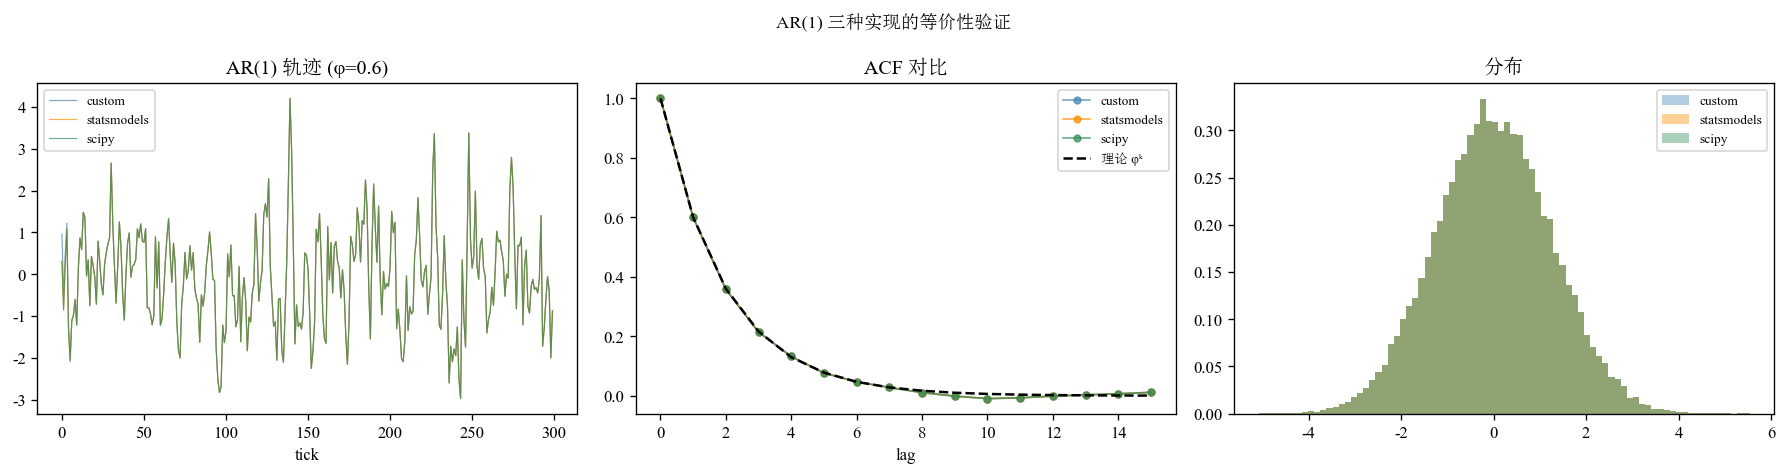

→ 三种实现在统计上完全等价，我们自己写的没问题。


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for x, name, color in [
    (x_custom, "custom", "steelblue"),
    (x_sm, "statsmodels", "darkorange"),
    (x_scipy, "scipy", "seagreen"),
]:
    axes[0].plot(x[:N_SHOW], lw=0.7, alpha=0.7, label=name, color=color)
axes[0].set_title(f"AR(1) 轨迹 (\u03c6={PHI})")
axes[0].set_xlabel("tick")
axes[0].legend(fontsize=8)

nlags_show = 15
lags_show = np.arange(nlags_show + 1)
for x, name, color in [
    (x_custom, "custom", "steelblue"),
    (x_sm, "statsmodels", "darkorange"),
    (x_scipy, "scipy", "seagreen"),
]:
    axes[1].plot(
        lags_show,
        acf(x[burn:], nlags=nlags_show, fft=True),
        "o-",
        ms=4,
        lw=1,
        alpha=0.7,
        label=name,
        color=color,
    )
axes[1].plot(lags_show, PHI**lags_show, "k--", lw=1.5, label="理论 \u03c6\u1d4f")
axes[1].set_title("ACF 对比")
axes[1].set_xlabel("lag")
axes[1].legend(fontsize=8)

for x, name, color in [
    (x_custom, "custom", "steelblue"),
    (x_sm, "statsmodels", "darkorange"),
    (x_scipy, "scipy", "seagreen"),
]:
    axes[2].hist(x[burn:], bins=80, density=True, alpha=0.4, label=name, color=color)
axes[2].set_title("分布")
axes[2].legend(fontsize=8)

fig.suptitle("AR(1) 三种实现的等价性验证", fontsize=11)
plt.tight_layout()
plt.show()
print("\u2192 三种实现在统计上完全等价，我们自己写的没问题。")

---
## 3. 四种气候强迫长什么样？

现在我们正式对比四种强迫类型。参数设置：

- **φ**：用树轮重建的经验值（约 0.50），这是**上界**——真实降水的 φ 更接近 0。
  这里取上界是为了让 ar1/ar1_trend 的持续性结构在图上更明显；注意这与第 2 节角度不同——第 2 节把 iid（φ=0、无持续性）当作最保守的零模型（iid 下都涌现窗口 → 不是持续性假象），本节则用偏高的 φ 展示『即便持续性取上界，强迫结构依然如此』。
- **趋势 β = 0.01 σ/年**：意思是每 100 年气候偏移 1 个标准差，算是中等偏强的趋势。
- **σ = 1**：标准化到单位方差。

### 生成四种序列

下面这个 cell 调用 `generate()` 分别生成 5 万个点的四种气候序列，存到 `forcings` 字典里。
所有序列用同一个随机种子（`rng_seed=7`），这样它们的『随机部分』是可比的，差异只来自过程本身的结构。

In [6]:
PHI_EMP = round(est_recon["phi"], 2)  # 树轮重建的经验 \u03c6
TREND = 0.01  # 每年趋势 0.01\u03c3（100 年偏移 1\u03c3）

forcings = {
    "iid": generate("iid", N, sigma=SIGMA, rng=np.random.default_rng(7)),
    f"ar1 (\u03c6={PHI_EMP})": generate(
        "ar1", N, sigma=SIGMA, phi=PHI_EMP, rng=np.random.default_rng(7)
    ),
    f"trend+noise (\u03b2={TREND})": generate(
        "trend_plus_noise",
        N,
        sigma=SIGMA,
        trend_per_year=TREND,
        rng=np.random.default_rng(7),
    ),
    f"ar1+trend (\u03c6={PHI_EMP}, \u03b2={TREND})": generate(
        "ar1_trend",
        N,
        sigma=SIGMA,
        phi=PHI_EMP,
        trend_per_year=TREND,
        rng=np.random.default_rng(7),
    ),
}

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
print(f"经验 \u03c6（树轮）= {PHI_EMP}")
print(f"趋势速率 = {TREND} \u03c3/年")

经验 φ（树轮）= 0.5
趋势速率 = 0.01 σ/年


### 三面板对比图

这是最重要的对比图，三个子图各回答一个问题：

**(a) 轨迹图**（上方全宽）：直观看四种序列『长什么样』。
- iid 看起来像纯噪声，没有连续几年偏高或偏低的『段落』。
- ar1 会出现明显的『连续偏高』或『连续偏低』的段落——这就是持续性。
- trend+noise 有一个肉眼可见的上升（或下降）趋势。
- ar1+trend 两者叠加。

**(b) 自相关函数**（左下）：用 ACF 量化持续性。
- iid 的 ACF 在 lag≥1 处约等于 0（蓝色线贴着零线）。
- ar1 的 ACF 按 φᵏ 指数衰减。
- trend+noise 的 ACF 在所有 lag 都接近 1，因为趋势项主导了长期相关性（注意这不是真正的『持续性』，只是趋势）。

**(c) 概率分布**（右下）：看四种序列的值分布。
- 对有趋势的序列先去掉线性趋势再看分布，否则不可比。
- ar1 的方差被放大到 σ²/(1−φ²)，所以分布更『胖』。

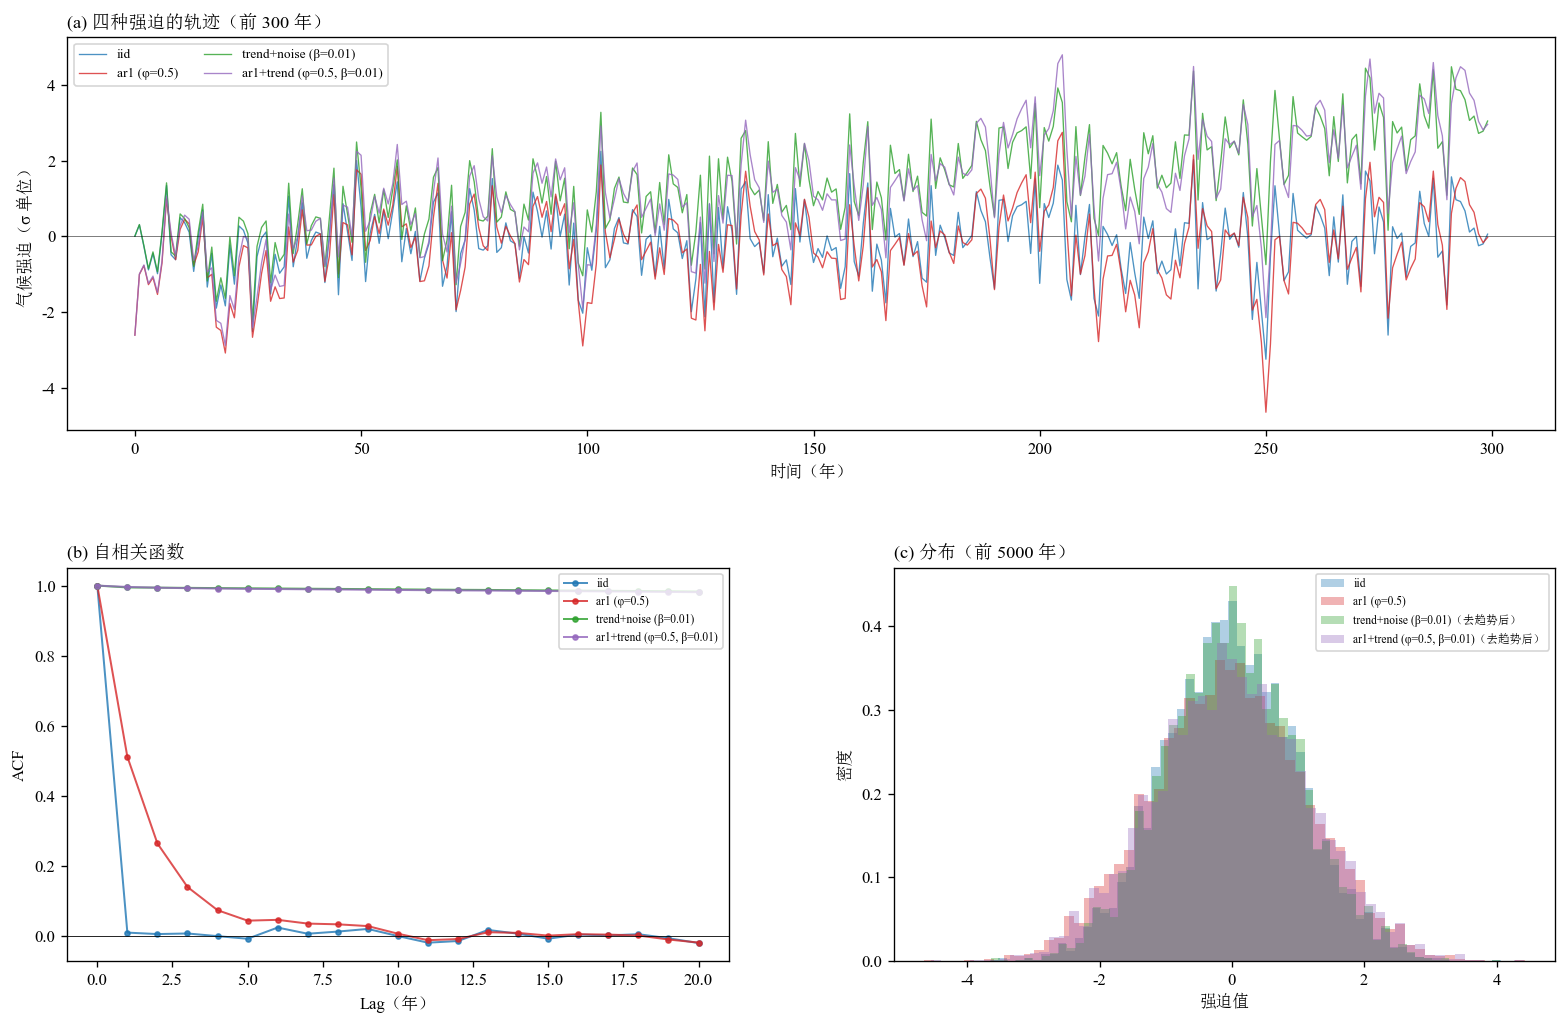

In [7]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, hspace=0.35, wspace=0.25)

# --- (a) 轨迹图 ---
ax_traj = fig.add_subplot(gs[0, :])
for (name, x), c in zip(forcings.items(), colors):
    ax_traj.plot(x[:N_SHOW], lw=0.8, alpha=0.8, label=name, color=c)
ax_traj.set_title("(a) 四种强迫的轨迹（前 300 年）", fontsize=11, loc="left")
ax_traj.set_xlabel("时间（年）")
ax_traj.set_ylabel("气候强迫（\u03c3 单位）")
ax_traj.legend(fontsize=8, ncol=2, loc="upper left")
ax_traj.axhline(0, color="k", lw=0.3)

# --- (b) ACF ---
ax_acf = fig.add_subplot(gs[1, 0])
max_lag_show = 20
lags_arr = np.arange(max_lag_show + 1)
for (name, x), c in zip(forcings.items(), colors):
    ax_acf.plot(
        lags_arr,
        acf(x[:5000], nlags=max_lag_show, fft=True),
        "o-",
        ms=3,
        lw=1.2,
        alpha=0.8,
        label=name,
        color=c,
    )
ax_acf.axhline(0, color="k", lw=0.5)
ax_acf.set_title("(b) 自相关函数", fontsize=11, loc="left")
ax_acf.set_xlabel("Lag（年）")
ax_acf.set_ylabel("ACF")
ax_acf.legend(fontsize=7, loc="upper right")

# --- (c) 分布 ---
ax_dist = fig.add_subplot(gs[1, 1])
for (name, x), c in zip(forcings.items(), colors):
    # 有趋势的序列先去趋势再看分布，否则不可比
    if "trend" in name:
        x_plot = x[:5000] - np.polyval(
            np.polyfit(np.arange(5000), x[:5000], 1), np.arange(5000)
        )
        lbl = name + "（去趋势后）"
    else:
        x_plot = x[:5000]
        lbl = name
    ax_dist.hist(x_plot, bins=60, density=True, alpha=0.35, color=c, label=lbl)
ax_dist.set_title("(c) 分布（前 5000 年）", fontsize=11, loc="left")
ax_dist.set_xlabel("强迫值")
ax_dist.set_ylabel("密度")
ax_dist.legend(fontsize=7)

plt.savefig("results/forcing_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

### 数值汇总

图是定性的，下面用数字精确呈现四种强迫的统计量：均值、标准差、lag-1 ACF、极值范围。

In [8]:
stats_tbl = pd.DataFrame(
    {
        "均值": {k: v.mean() for k, v in forcings.items()},
        "标准差": {k: v.std(ddof=1) for k, v in forcings.items()},
        "lag-1 ACF": {k: acf(v, nlags=1, fft=True)[1] for k, v in forcings.items()},
        "最小值": {k: v.min() for k, v in forcings.items()},
        "最大值": {k: v.max() for k, v in forcings.items()},
    }
)
stats_tbl.style.format("{:.4f}")

,均值,标准差,lag-1 ACF,最小值,最大值
iid,-0.0055,0.9967,0.0030,-4.5022,4.0616
ar1 (φ=0.5),-0.0111,1.1559,0.5064,-4.7016,4.4329
trend+noise (β=0.01),249.9895,144.3456,0.9999,-2.2568,501.5981
"ar1+trend (φ=0.5, β=0.01)",249.9839,144.3500,0.9999,-2.8877,502.3264


### 小结：四种强迫有什么区别？

| 强迫类型 | 自相关 | 分布 | 直观感受 |
|----------|--------|------|----------|
| **iid** | lag≥1 ≈ 0（无记忆） | 对称高斯 | 纯粹的『随机乱跳』，没有连续性 |
| **ar1** | 按 φᵏ 衰减（有记忆） | 更宽的高斯 | 会出现连续几年偏干或偏湿的『段落』 |
| **trend+noise** | 所有 lag 都 ≈ 1 | 趋势主导 | 整体在上升/下降，但年际波动还是随机的 |
| **ar1+trend** | 持续性 + 趋势叠加 | 最复杂 | 最接近真实气候：有惯性，也有长期变化 |

**关键论点**：如果 SBS 机制在 iid（最简单、最不利的情况）下就能涌现 ~30 年窗口，
那说明这个窗口是代际记忆的产物，**不是气候持续性造成的假象**。这比『用更真实的气候模型也能复现』
要更强。**本笔记本只对比四种强迫本身的统计性质**；窗口在四种强迫下是否都稳健，由 `climate_scenario_experiments.py` 的 ABM 峰值矩阵给出（见 `reports/results/climate_scenarios/`）。

---
## 4. φ 从 0 调到 0.9，会发生什么？

这一节回答审稿人关于『持续性敏感性』的问题：如果气候确实有持续性（φ > 0），
AR(1) 过程长什么样？不同 φ 差别多大？

我们扫描 φ ∈ {0, 0.1, 0.3, 0.5, 0.7, 0.9}：
- φ = 0 就是 iid（纯白噪声）
- φ = 0.1–0.3 是年降水的现实范围（器测数据显示 φ ≈ 0）
- φ = 0.5 是树轮重建的值（上界）
- φ = 0.7–0.9 是不太现实的极端情况，但作为压力测试有用

三个子图分别展示：
- **(a) 轨迹**：φ 越大，序列越『光滑』（高频波动被抑制）
- **(b) ACF**：φ 越大，自相关衰减越慢（记忆越长）
- **(c) 方差**：φ 越大，方差越大（圆点=实测，叉=理论 σ²/(1−φ²)，两者应重合）

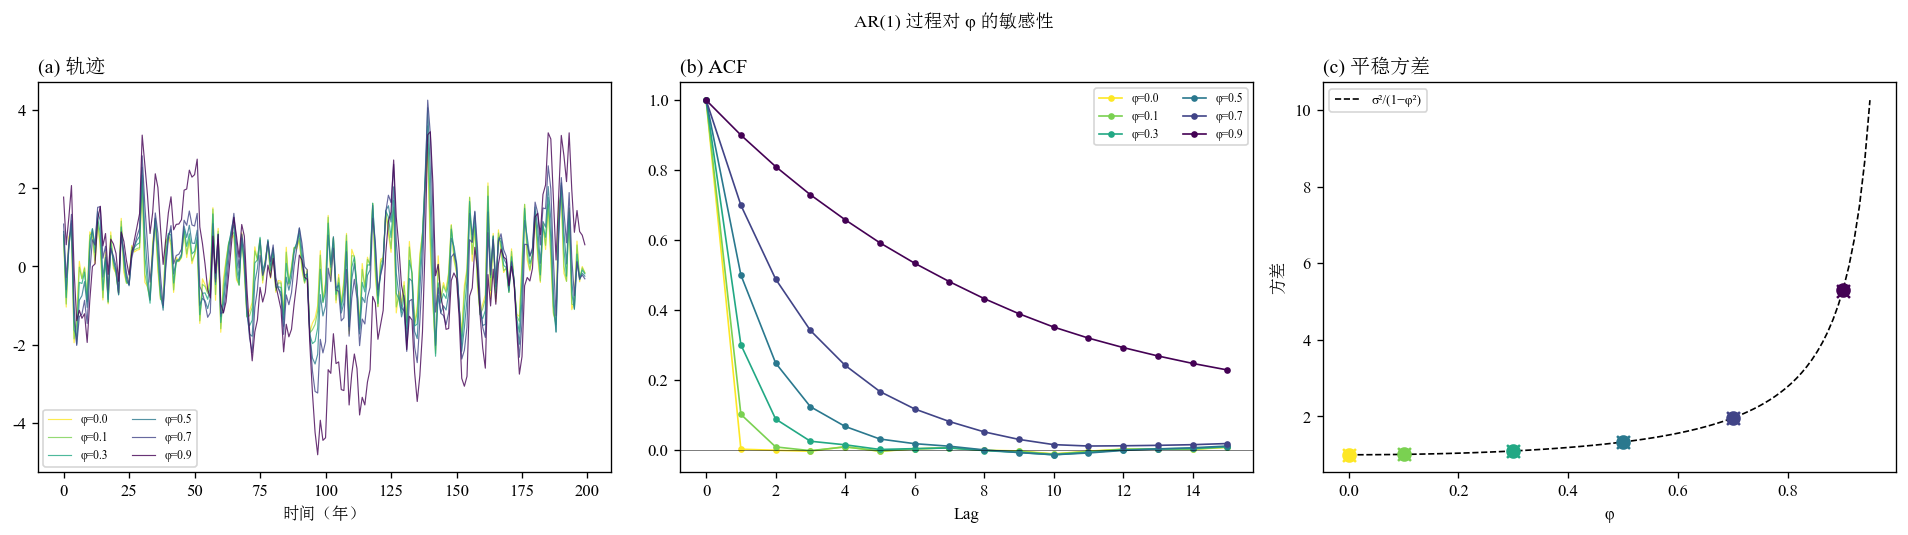


★ 器测数据的 φ ≈ -0.098（几乎是 iid）
★ 树轮重建的 φ ≈ 0.496（上界，平滑假象）
→ 年尺度旱涝变率的合理 φ 范围：0.0 – 0.3


In [9]:
phi_values = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
cmap = plt.cm.viridis_r

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, phi_val in enumerate(phi_values):
    color = cmap(i / (len(phi_values) - 1))
    x = generate("ar1", N, sigma=SIGMA, phi=phi_val, rng=np.random.default_rng(42))

    # 轨迹
    axes[0].plot(x[:200], lw=0.7, alpha=0.8, color=color, label=f"\u03c6={phi_val}")

    # ACF
    acf_vals = acf(x[500:], nlags=15, fft=True)
    axes[1].plot(
        np.arange(16),
        acf_vals,
        "o-",
        ms=3,
        lw=1,
        color=color,
        label=f"\u03c6={phi_val}",
    )

    # 方差（圆点 = 实测，叉 = 理论）
    theo = SIGMA**2 / (1 - phi_val**2) if phi_val < 1 else np.nan
    axes[2].scatter(phi_val, x[500:].var(ddof=1), color=color, s=60, zorder=3)
    axes[2].scatter(phi_val, theo, color=color, s=60, marker="x", zorder=3)

axes[0].set_title("(a) 轨迹", loc="left")
axes[0].set_xlabel("时间（年）")
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_title("(b) ACF", loc="left")
axes[1].set_xlabel("Lag")
axes[1].axhline(0, color="k", lw=0.3)
axes[1].legend(fontsize=7, ncol=2)

axes[2].set_title("(c) 平稳方差", loc="left")
axes[2].set_xlabel("\u03c6")
axes[2].set_ylabel("方差")
phi_line = np.linspace(0, 0.95, 100)
axes[2].plot(
    phi_line,
    SIGMA**2 / (1 - phi_line**2),
    "k--",
    lw=1,
    label="\u03c3\u00b2/(1\u2212\u03c6\u00b2)",
)
axes[2].legend(fontsize=8)

fig.suptitle("AR(1) 过程对 \u03c6 的敏感性", fontsize=11)
plt.tight_layout()
plt.savefig("results/phi_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\n\u2605 器测数据的 \u03c6 \u2248 {est_instr['phi']:.3f}（几乎是 iid）")
print(f"\u2605 树轮重建的 \u03c6 \u2248 {est_recon['phi']:.3f}（上界，平滑假象）")
print(f"\u2192 年尺度旱涝变率的合理 \u03c6 范围：0.0 \u2013 0.3")

---
## 5. 换成季度/月度分辨率，结果会变吗？

审稿人的另一个担心是：如果 ABM 用季度或月度步长跑（`step_per_year > 1`），
而不是年步长，~30 年窗口还在吗？

这里有个技术问题：如果每个月独立生成一个噪声值，然后把 12 个月平均/求和成一年，
年尺度的标准差会发生变化（平均会变小，求和会变大）。所以我们需要在月/季尺度调整 σ，
让年聚合后的 σ 保持不变。这就是 `sigma_tick_from_sigma_year()` 做的事情。

下面验证：不管 `step_per_year` 是 1、2、4 还是 12，年聚合后的标准差都约等于 1.0。

### 数值验证

对三种聚合方式 × 四种时间分辨率，各生成 20 万年的数据，算年聚合后的标准差。

- **mean**：一年内取平均（物理含义：平均降水量）
- **sum**：一年内求和（物理含义：年累积降水量）
- **last**：只取一年中最后一个时间步的值（物理含义：年末快照）

如果 σ 换算正确，所有行的『年聚合后 std』都应该约等于 1.0（误差 < 0.5%）。

In [10]:
sigma_year = 1.0
steps_to_test = [1, 2, 4, 12]
N_AGG = 200_000  # 20 万年的数据，保证统计量稳定

results = []
for agg_method in ["mean", "sum", "last"]:
    for step in steps_to_test:
        # 先算出这个分辨率下应该用的 \u03c3_tick
        s_tick = sigma_tick_from_sigma_year(
            sigma_year=sigma_year,
            step_per_year=step,
            subannual_aggregation=agg_method,
        )
        # 生成 tick 级别序列
        x = generate("iid", N_AGG * step, sigma=s_tick, rng=np.random.default_rng(99))
        # 聚合到年级别
        yearly = x.reshape(-1, step)
        if agg_method == "mean":
            y_agg = yearly.mean(axis=1)
        elif agg_method == "sum":
            y_agg = yearly.sum(axis=1)
        else:
            y_agg = yearly[:, -1]
        results.append(
            {
                "聚合方式": agg_method,
                "step_per_year": step,
                "\u03c3_tick": s_tick,
                "年聚合后 std": y_agg.std(ddof=1),
                "目标": sigma_year,
            }
        )

df_agg = pd.DataFrame(results)
df_agg["误差 %"] = 100 * (df_agg["年聚合后 std"] - df_agg["目标"]) / df_agg["目标"]
df_agg.style.format({"\u03c3_tick": "{:.4f}", "年聚合后 std": "{:.4f}", "误差 %": "{:.2f}"})

,聚合方式,step_per_year,σ_tick,年聚合后 std,目标,误差 %
0,mean,1,1.0000,0.9982,1.000000,-0.18
1,mean,2,1.4142,0.9998,1.000000,-0.02
2,mean,4,2.0000,0.9978,1.000000,-0.22
3,mean,12,3.4641,1.0006,1.000000,0.06
4,sum,1,1.0000,0.9982,1.000000,-0.18
5,sum,2,0.7071,0.9998,1.000000,-0.02
6,sum,4,0.5000,0.9978,1.000000,-0.22
7,sum,12,0.2887,1.0006,1.000000,0.06
8,last,1,1.0000,0.9982,1.000000,-0.18
9,last,2,1.0000,0.9991,1.000000,-0.09


### 柱状图验证

三张子图分别对应 mean / sum / last 三种聚合方式。每根柱子的高度是年聚合后的标准差，
红色虚线是目标值 σ=1.0。柱子如果都踩在红线上，说明换算正确。

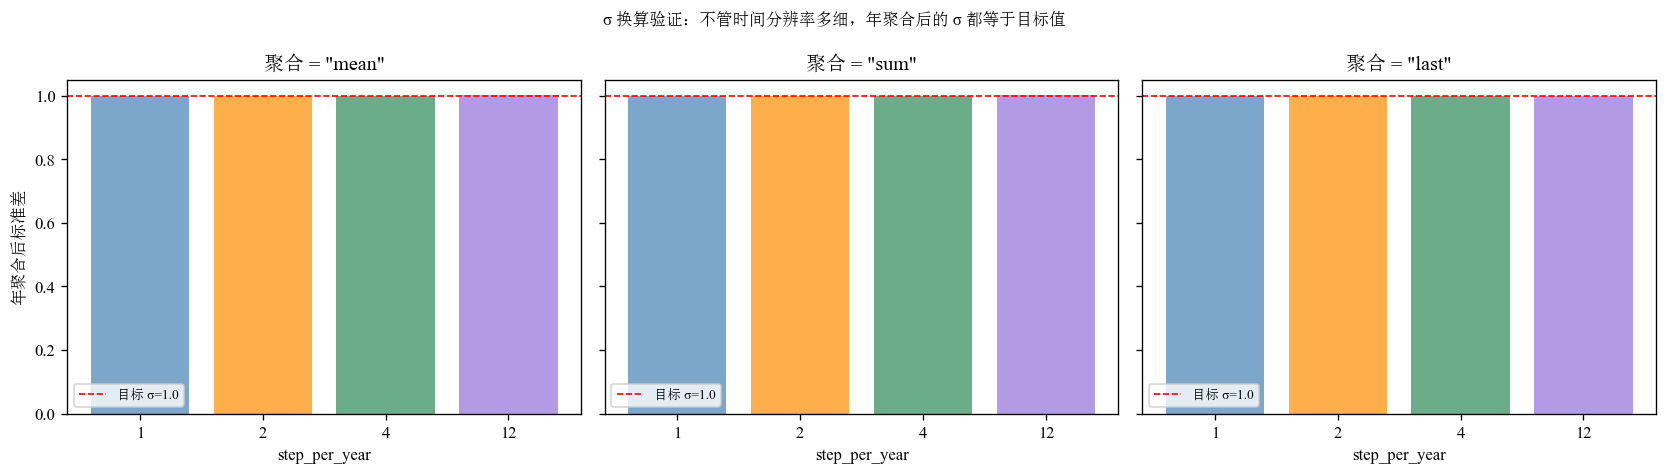

→ 所有组合的年聚合 σ ≈ 1.0（误差 < 0.5%），换算公式正确。


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, agg_method in enumerate(["mean", "sum", "last"]):
    sub = df_agg[df_agg["聚合方式"] == agg_method]
    axes[i].bar(
        [str(s) for s in sub["step_per_year"]],
        sub["年聚合后 std"],
        alpha=0.7,
        color=["steelblue", "darkorange", "seagreen", "mediumpurple"],
    )
    axes[i].axhline(
        sigma_year, color="red", ls="--", lw=1, label=f"目标 \u03c3={sigma_year}"
    )
    axes[i].set_title(f'聚合 = "{agg_method}"')
    axes[i].set_xlabel("step_per_year")
    axes[i].legend(fontsize=8)
axes[0].set_ylabel("年聚合后标准差")
fig.suptitle("\u03c3 换算验证：不管时间分辨率多细，年聚合后的 \u03c3 都等于目标值", fontsize=10)
plt.tight_layout()
plt.savefig("results/subannual_validation.png", dpi=200, bbox_inches="tight")
plt.show()
print("\u2192 所有组合的年聚合 \u03c3 \u2248 1.0（误差 < 0.5%），换算公式正确。")

---
## 6. 功率谱：从频率角度看四种强迫的区别

前面用 ACF（时域）分析了持续性，这里换成**频域**角度——功率谱密度（PSD）。

功率谱回答的是：这个序列的变率主要集中在哪些频率？

- **白噪声（iid）**：所有频率的能量一样多——谱线是平的。
- **红噪声（AR(1)）**：低频能量多、高频能量少——谱线从左到右下降。
  这就是 Hasselmann (1976) 的经典理论：天气（白噪声）被海洋等缓慢系统『滤波』后变成红噪声。
- **趋势**：趋势会在最低频（接近 0）处产生极大的能量尖峰。

黑色虚线是 AR(1) 的理论功率谱，用来验证我们的生成器在频域上也是对的。

**对有趋势的序列，先去掉线性趋势再算 PSD，否则趋势项会淹没其他所有信号。**

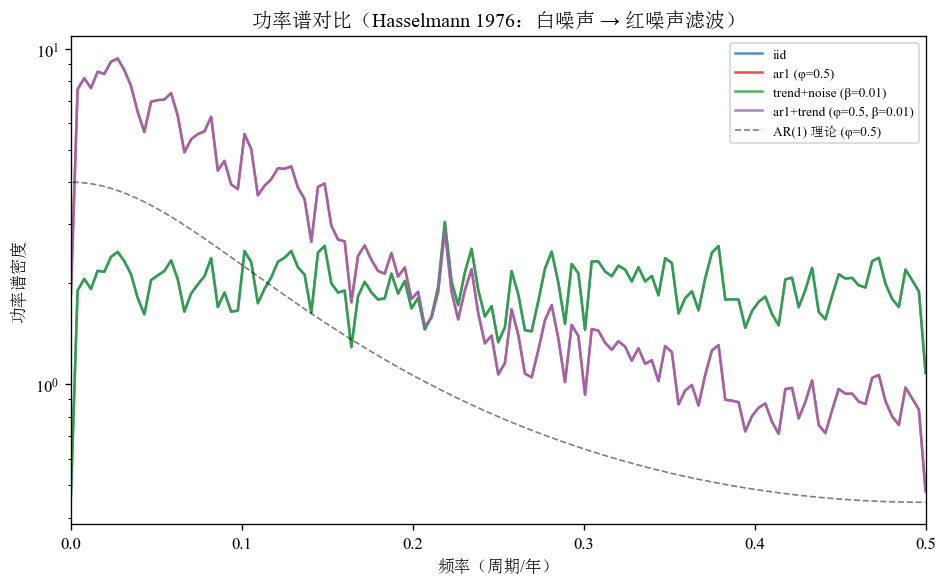

In [12]:
from scipy.signal import welch

fig, ax = plt.subplots(figsize=(8, 5))

for (name, x), c in zip(forcings.items(), colors):
    # 有趋势的序列先去掉线性趋势再算 PSD
    if "trend" in name:
        x_use = x[:5000] - np.polyval(
            np.polyfit(np.arange(5000), x[:5000], 1), np.arange(5000)
        )
    else:
        x_use = x[:5000]
    freq, psd = welch(x_use, fs=1.0, nperseg=256)
    ax.semilogy(freq, psd, lw=1.5, alpha=0.8, label=name, color=c)

# AR(1) 理论功率谱：S(f) = \u03c3\u00b2 / |1 - \u03c6\u00b7e^{-2\u03c0if}|\u00b2
f_theo = np.linspace(0.001, 0.5, 500)
psd_ar1_theo = SIGMA**2 / (
    1 - 2 * PHI_EMP * np.cos(2 * np.pi * f_theo) + PHI_EMP**2
)
ax.semilogy(
    f_theo, psd_ar1_theo, "k--", lw=1, alpha=0.5, label=f"AR(1) 理论 (\u03c6={PHI_EMP})"
)

ax.set_xlabel("频率（周期/年）")
ax.set_ylabel("功率谱密度")
ax.set_title("功率谱对比（Hasselmann 1976：白噪声 \u2192 红噪声滤波）")
ax.legend(fontsize=8)
ax.set_xlim(0, 0.5)

plt.tight_layout()
plt.savefig("results/power_spectrum.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 7. 全部结论汇总

### 经验发现

| 发现 | 对 ABM 的含义 |
|------|-------------|
| 器测年降水的 φ ≈ −0.10（几乎就是 iid） | **iid 基线是有经验依据的**，不是拍脑袋的假设 |
| 树轮重建的 φ ≈ 0.50（平滑假象） | φ=0.5 可以当做敏感性分析的上界 |
| 我们自己写的 AR(1) = statsmodels = scipy | 实现没有 bug，可以放心用 |
| σ 换算在所有分辨率下都精确（<0.5% 误差） | 可以自由切换年/季/月步长而不影响可比性 |
| ar1+trend 过程可用 | 可以做『最真实情况』的敏感性检验 |

### 论证逻辑（回应审稿人的核心思路）

1. **为什么用 iid？** 因为器测数据表明年降水确实接近 iid。而且 iid 是最保守的假设——
   如果 ~30 年窗口在零持续性下就能涌现，那它一定是代际记忆机制的产物，不可能是气候结构的假象。

2. **如果气候有持续性呢？** 我们准备了 AR(1) 敏感性实验，扫描 φ 从 0 到 0.9。

3. **如果有趋势呢？** 我们准备了 trend 和 ar1+trend 的敏感性实验。

4. **如果不用年步长呢？** σ 换算保证了季度/月度步长与年步长的结果可比。

### 下一步：运行 ABM 敏感性扫描

```bash
# A: 持续性敏感性
uv run python shifting_baseline/abm.py --multirun \\
    model.climate_process=ar1 model.climate_phi=0.0,0.1,0.3,0.5,0.7,0.9

# B: 时间分辨率敏感性
uv run python shifting_baseline/abm.py --multirun \\
    model.step_per_year=1,2,4,12 model.climate_process=iid

# C: 趋势敏感性
uv run python shifting_baseline/abm.py --multirun \\
    model.climate_process=trend_plus_noise model.climate_trend=0.0,0.005,0.01,0.02

# D: 最真实场景（AR(1) + 趋势）
uv run python shifting_baseline/abm.py --multirun \\
    model.climate_process=ar1_trend model.climate_phi=0.3,0.5 model.climate_trend=0.005,0.01
```

### 引用的关键文献

- **Hasselmann (1976)** *Tellus* 28(6):473-485 — 随机气候模型理论：白噪声 → AR(1) 红噪声
- **Mudelsee (2002)** *Computers & Geosciences* 28(1):69-72 — AR(1) 持续性估计方法
- **Wilks & Wilby (1999)** *Prog. Phys. Geog.* 23(3):329-357 — 随机天气生成器综述（日尺度，不适用于年尺度 ABM）
- **Schluter et al. (2012)** *Nat. Resour. Model.* 25(1):219-272 — 社会-生态系统 ABM 中简化气候驱动的标准做法